In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

import joblib

c:\Users\deeks\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.drop("CustomerID", axis=1, inplace=True)

In [4]:
X = df[
    ["Annual Income (k$)",
     "Spending Score (1-100)"]
]

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
for eps in [0.2,0.3,0.4,0.5]:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    print(
        f"eps={eps} | clusters={n_clusters} | noise={noise}"
    )

eps=0.2 | clusters=7 | noise=77
eps=0.3 | clusters=7 | noise=35
eps=0.4 | clusters=4 | noise=15
eps=0.5 | clusters=2 | noise=8


In [8]:
for eps in [0.2,0.3,0.4,0.5]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:

        score = silhouette_score(
            X_scaled,
            labels
        )

        print(
            f"eps={eps} | silhouette={score:.4f}"
        )

eps=0.2 | silhouette=0.1406
eps=0.3 | silhouette=0.3161
eps=0.4 | silhouette=0.4133
eps=0.5 | silhouette=0.3504


In [9]:
dbscan = DBSCAN(
    eps=0.4,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

In [10]:
df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,0
1,Male,21,15,81,0
2,Female,20,16,6,1
3,Female,23,16,77,0
4,Female,31,17,40,0


In [19]:
joblib.dump(
    df,
    "models/dbscan_clustered_df.pkl"
)

['models/dbscan_clustered_df.pkl']

In [11]:
df["Cluster"].value_counts().sort_index()

Cluster
-1     15
 0    115
 1     11
 2     32
 3     27
Name: count, dtype: int64

In [12]:
sil_score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.41325830390002166


In [13]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(
    X_scaled,
    clusters
)

print("Davies-Bouldin Score:", db_score)

Davies-Bouldin Score: 1.421088125095285


In [14]:
cluster_summary = df[
    df["Cluster"] != -1
].groupby("Cluster")[
    ["Annual Income (k$)",
     "Spending Score (1-100)"]
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,48.304348,51.730435
1,23.727273,8.909091
2,80.875000,83.625000
3,83.925926,14.444444


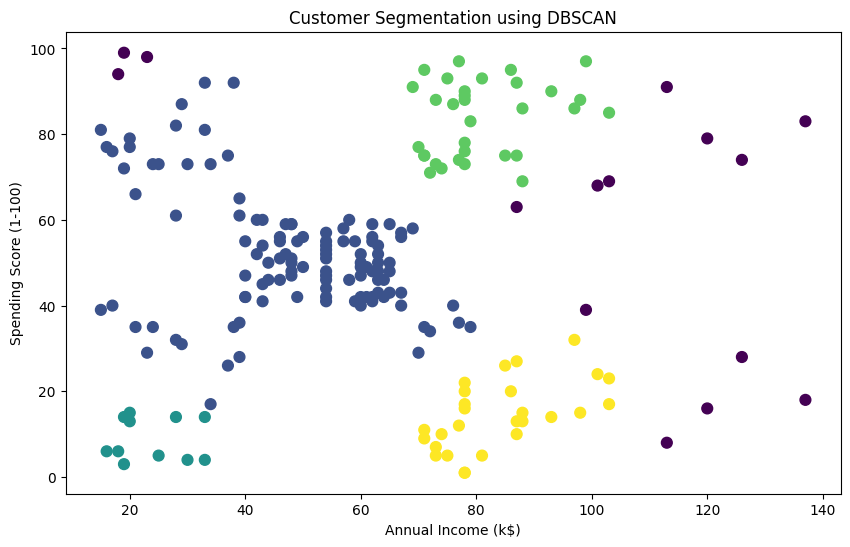

In [15]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using DBSCAN")

plt.show()

In [16]:
cluster_centers = df[
    df["Cluster"] != -1
].groupby("Cluster")[
    ["Annual Income (k$)",
     "Spending Score (1-100)"]
].mean()

cluster_centers

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,48.304348,51.730435
1,23.727273,8.909091
2,80.875000,83.625000
3,83.925926,14.444444


In [ ]:
import joblib



joblib.dump(
    scaler,
    "models/scaler.pkl"
)

['models/scaler.pkl']

In [18]:
joblib.dump(
    cluster_centers,
    "models/cluster_centers.pkl"
)

['models/cluster_centers.pkl']